# 6. Florence-2 Zero-Shot Visual Experiments
Florence-2 is Microsoft's advanced unified vision-language model. It performs multiple tasks (Object Detection, Captioning, Grounding) using textual prompt formatting.

In this notebook, we:
1. Load Florence-2.
2. Run standard `<OD>` (general object detection).
3. Run `<CAPTION_TO_PHRASE_GROUNDING>` (phrase grounding for specific fashion items).
4. Compare results.



In [1]:
import os
import sys

sys.path.append(os.path.abspath("."))

from fashion_detector.config import Config
from fashion_detector.models.florence2 import Florence2Detector
from fashion_detector.utils import load_image, generate_interactive_html
from IPython.display import HTML

config = Config("config/config.yaml")

# Initialize Florence-2
detector = Florence2Detector(config)
detector.load_model()

/Users/sunnyraj/code_files/git_repos/image-segments/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-07-21 11:03:58] [INFO] [fashion_detector:config.py:159] - Configuration loaded from config/config.yaml. Device set to: mps
[2026-07-21 11:03:58] [INFO] [fashion_detector:florence2.py:22] - Florence-2 Detector initialized with model: microsoft/Florence-2-base, confidence threshold: 0.3
[2026-07-21 11:03:58] [INFO] [fashion_detector:florence2.py:25] - Florence-2 Detector default lifestyle categories: ['shirt', 't-shirt', 'polo', 'sweater', 'hoodie', 'jacket', 'blazer', 'coat', 'dress', 'top', 'jeans', 'pants', 'shorts', 'skirt', 'suit', 'jumpsuit', 'scarf', 'handbag', 'backpack', 'wallet', 'belt', 'watch', 'bracelet', 'necklace', 'earrings', 'ring', 'hat', 'cap', 'sunglasses', 'shoes', 'boots', 'sneakers']
[2026-07-21 11:03:58] [INFO] [fashion_detector:florence2.py:37] - Loading Florence-2 model: microsoft/Florence-2-base on device: mps


`torch_dtype` is deprecated! Use `dtype` instead!


[2026-07-21 11:04:07] [INFO] [fashion_detector:florence2.py:110] - Florence-2 model loaded successfully.


## Task 1: General Object Detection (`<OD>`)
This task automatically outputs boxes and names without specifying categories.



In [2]:
image = load_image("data/fashion_model_street.jpg")
detections_od = detector.detect(image, task="<OD>")

print("Florence-2 <OD> Detections:")
for d in detections_od:
    print(f"- {d.label}: box={list(map(int, d.box))}")

[2026-07-21 11:04:08] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: data/fashion_model_street.jpg
[2026-07-21 11:04:08] [INFO] [fashion_detector:logging.py:98] - Starting: Florence-2 Inference
[2026-07-21 11:04:08] [INFO] [fashion_detector:florence2.py:141] - Florence-2 running task: <OD>
[2026-07-21 11:04:10] [INFO] [fashion_detector:florence2.py:249] - Florence-2 detected 3 fashion items (filtered from 5 total).
[2026-07-21 11:04:10] [INFO] [fashion_detector:logging.py:103] - Completed: Florence-2 Inference in 1.5737 seconds
Florence-2 <OD> Detections:
- shoes: box=[271, 906, 342, 1024]
- shoes: box=[518, 886, 575, 1017]
- pants: box=[279, 378, 584, 916]


## Task 2: Phrase Grounding (`<CAPTION_TO_PHRASE_GROUNDING>`)
We ask the model to look specifically for our fashion categories.



In [3]:
fashion_queries = ["dress", "hat", "handbag", "sunglasses", "shoes"]
detections_grounding = detector.detect(
    image, task="<CAPTION_TO_PHRASE_GROUNDING>", queries=fashion_queries
)

print("Florence-2 Phrase Grounding Detections:")
for d in detections_grounding:
    print(f"- {d.label}: box={list(map(int, d.box))}")

[2026-07-21 11:04:13] [INFO] [fashion_detector:logging.py:98] - Starting: Florence-2 Inference
[2026-07-21 11:04:13] [INFO] [fashion_detector:florence2.py:141] - Florence-2 running task: <CAPTION_TO_PHRASE_GROUNDING>
[2026-07-21 11:04:14] [INFO] [fashion_detector:florence2.py:249] - Florence-2 detected 3 fashion items (filtered from 3 total).
[2026-07-21 11:04:14] [INFO] [fashion_detector:logging.py:103] - Completed: Florence-2 Inference in 0.8318 seconds
Florence-2 Phrase Grounding Detections:
- dress: box=[263, 64, 588, 1023]
- dress: box=[264, 142, 587, 913]
- sunglasses: box=[362, 93, 439, 122]


## Visualize Grounding Detections



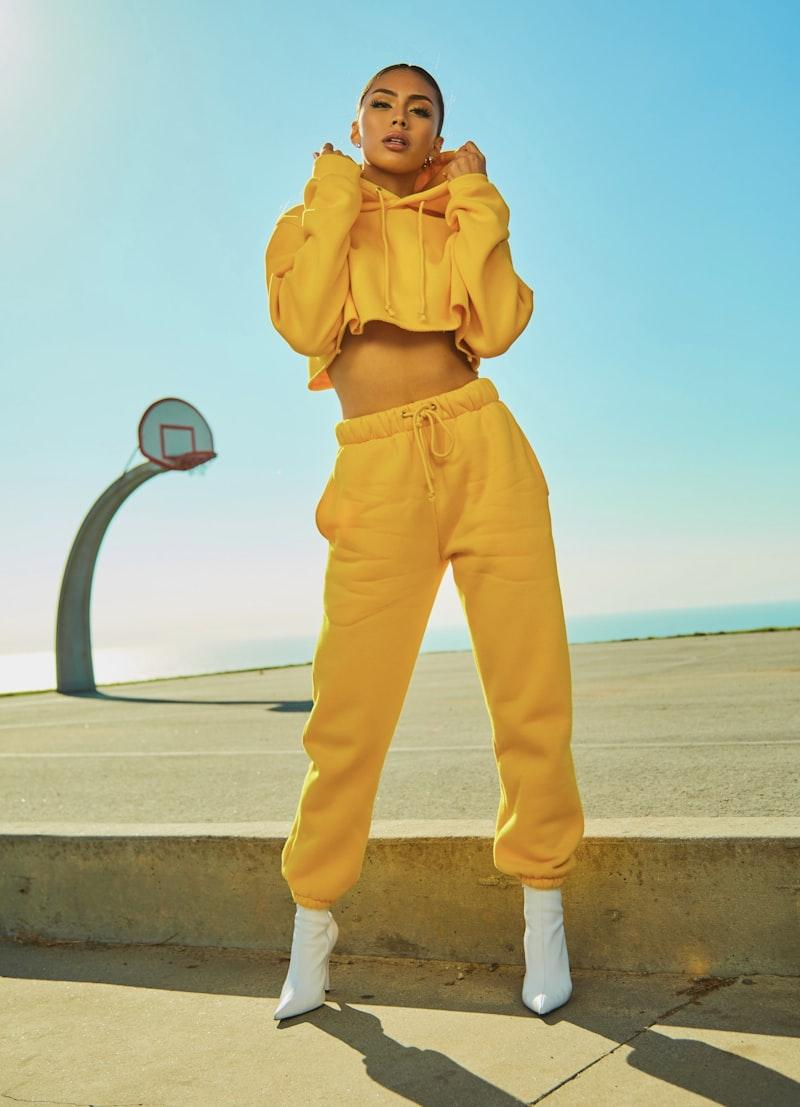

In [4]:
html_str = generate_interactive_html(
    image, detections_grounding, title="Florence-2 Grounding Detections"
)
HTML(html_str)

In [16]:
import base64
import io
from typing import Dict, List, Union

import matplotlib.pyplot as plt
from IPython.display import HTML, display
from PIL import Image


def display_img(image: Image.Image, figsize=(6, 6)):
    """Display a PIL image inside Jupyter."""
    plt.figure(figsize=figsize)
    plt.imshow(image)
    plt.axis("off")
    plt.show()


def visualize_detections(
    image: Union[str, Image.Image],
    detections: List[Dict],
    max_width: int = 700,
    show_score: bool = True,
):
    """
    Display clickable detections in a Jupyter notebook.

    Supports:
        - image path
        - PIL Image

    Detection format:

    {
        "label": "...",
        "score": 0.91,
        "box": [xmin, ymin, xmax, ymax]
    }
    """

    # -------------------------------------------------------------
    # Load image
    # -------------------------------------------------------------

    if isinstance(image, str):

        img = Image.open(image).convert("RGB")

        with open(image, "rb") as f:
            img_bytes = f.read()

    elif isinstance(image, Image.Image):

        img = image.convert("RGB")

        buffer = io.BytesIO()
        img.save(buffer, format="JPEG")
        img_bytes = buffer.getvalue()

    else:
        raise TypeError(
            "image must be a file path or PIL.Image"
        )

    img_width, img_height = img.size

    img_base64 = base64.b64encode(img_bytes).decode("utf-8")

    html = f"""
    <div style="
        position:relative;
        display:inline-block;
        max-width:{max_width}px;
    ">
        <img
            src="data:image/jpeg;base64,{img_base64}"
            style="
                width:100%;
                display:block;
                height:auto;
            "
        />
    """

    # -------------------------------------------------------------
    # Draw detections
    # -------------------------------------------------------------

    COLORS = [
        "#00E5FF",
        "#00C853",
        "#FF5252",
        "#FFAB00",
        "#AA00FF",
        "#2979FF",
        "#EC407A",
        "#7CB342",
    ]

    for idx, det in enumerate(detections):

        box = det.get("box") or det.get("bbox")

        if box is None:
            continue

        xmin, ymin, xmax, ymax = box

        label = det.get("label", "object")
        score = det.get("score")

        area = (xmax - xmin) * (ymax - ymin)

        label_text = (
            f"{label.upper()} ({score:.2f})"
            if show_score and score is not None
            else label.upper()
        )

        color = COLORS[idx % len(COLORS)]

        html += f"""
        <div
            title="{label}"
            onclick="alert(
                'Label : {label}\\n'
                + 'Score : {score}\\n'
                + 'Area : {area}px²\\n'
                + 'Box : {box}'
            )"
            style="
                position:absolute;
                left:{xmin/img_width*100:.3f}%;
                top:{ymin/img_height*100:.3f}%;
                width:{(xmax-xmin)/img_width*100:.3f}%;
                height:{(ymax-ymin)/img_height*100:.3f}%;

                border:3px solid {color};
                background:rgba(255,255,255,.05);
                cursor:pointer;
                transition:.2s;
                box-sizing:border-box;
            "

            onmouseover="
                this.style.background='rgba(255,255,255,.25)';
            "

            onmouseout="
                this.style.background='rgba(255,255,255,.05)';
            "
        >

            <div
                style="
                    position:absolute;
                    left:0;
                    top:-24px;

                    background:{color};
                    color:white;

                    font-size:12px;
                    font-weight:bold;

                    padding:2px 6px;
                    white-space:nowrap;
                "
            >
                {label_text}
            </div>

        </div>
        """

    html += "</div>"

    display(HTML(html))


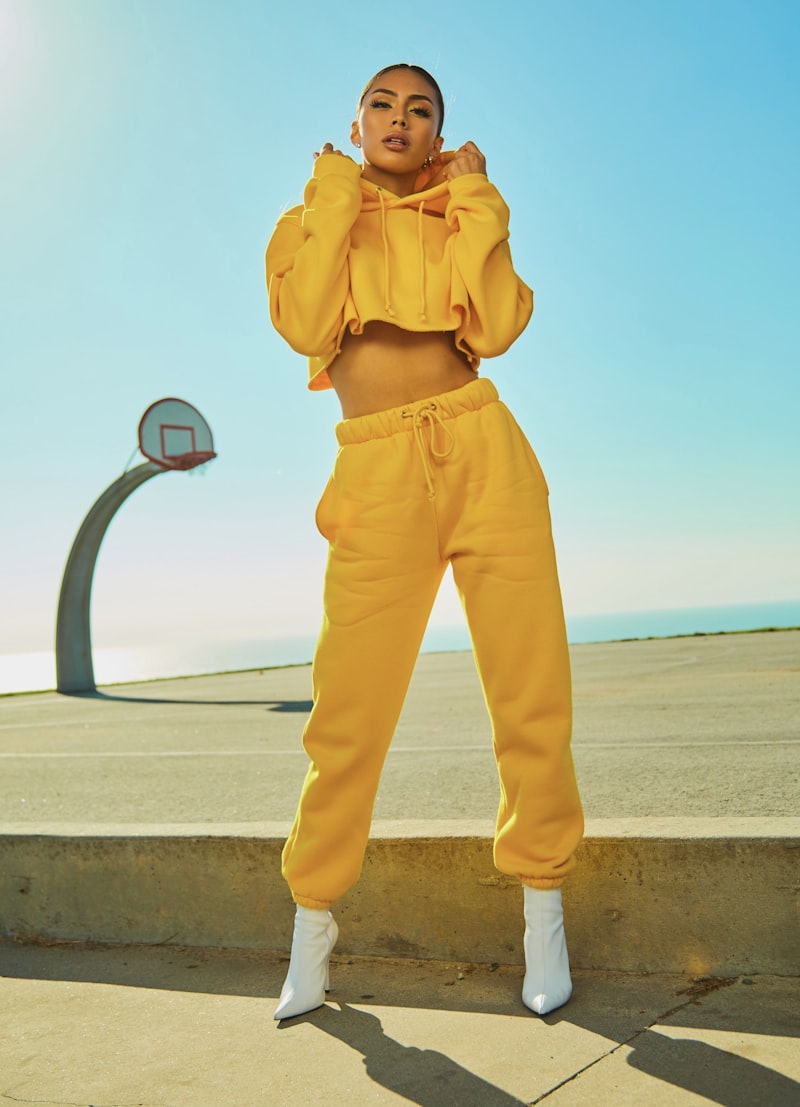

In [17]:
visualize_detections("data/fashion_model_street.jpg", [a.to_dict() for a in detections_grounding])

In [12]:
cats = ['dresses',
 'tops',
 'sweaters',
 'shirts',
 'jackets blazers',
 'coats',
 'pants',
 'jeans',
 'skirts',
 'suits sets',
 'jumpsuits',
 'sneakers',
 'flats',
 'loafers',
 'mules slides',
 'heels',
 'sandals',
 'boots',
 'tote bags',
 'shoulder bags',
 'crossbody bags',
 'handle bags',
 'backpacks',
 'belt bags',
 'clutches',
 'sunglasses',
 'scarves shawls',
 'belts',
 'wallets',
 'hats',
 'watches',
 'jewelry',
 'earrings',
 'necklaces',
 'bracelets',
 'rings',
 'brooches',
 't shirts',
 'shirts',
 'sweaters',
 'jackets',
 'blazers',
 'coats',
 'pants',
 'jeans',
 'suits',
 'shorts',
 'dress shoes',
 'loafers',
 'sneakers',
 'boots',
 'sandals',
 'briefcases',
 'backpacks',
 'duffel bags',
 'messenger bags',
 'tote bags',
 'sunglasses',
 'belts',
 'ties',
 'scarves',
 'wallets',
 'hats',
 'watches']

detected_products = detector.detect(
    image, task="<CAPTION_TO_PHRASE_GROUNDING>", queries=cats
)

[2026-07-21 11:11:37] [INFO] [fashion_detector:logging.py:98] - Starting: Florence-2 Inference
[2026-07-21 11:11:37] [INFO] [fashion_detector:florence2.py:141] - Florence-2 running task: <CAPTION_TO_PHRASE_GROUNDING>
[2026-07-21 11:12:32] [INFO] [fashion_detector:florence2.py:249] - Florence-2 detected 54 fashion items (filtered from 66 total).
[2026-07-21 11:12:32] [INFO] [fashion_detector:logging.py:103] - Completed: Florence-2 Inference in 54.8278 seconds


In [15]:
import pandas as pd
pd.DataFrame(detector._to_dict(detected_products))

,box,label,score,has_mask,metadata
0,"[262.8000183105469, 147.7845001220703, 537.200...",dress,1.0,False,{'raw_label': 'dresses'}
1,"[262.8000183105469, 148.89149475097656, 537.20...",dress,1.0,False,{'raw_label': 'dresses'}
2,"[262.8000183105469, 148.89149475097656, 536.40...",sweater,1.0,False,{'raw_label': 'sweaters'}
3,"[262.8000183105469, 149.99850463867188, 536.40...",sweater,1.0,False,{'raw_label': 'sweaters'}
4,"[262.8000183105469, 148.89149475097656, 535.60...",shirt,1.0,False,{'raw_label': 'shirts'}
5,"[262.8000183105469, 151.10549926757812, 536.40...",shirt,1.0,False,{'raw_label': 'shirts'}
6,"[262.8000183105469, 148.89149475097656, 538.0,...",jacket,1.0,False,{'raw_label': 'jackets'}
7,"[262.8000183105469, 147.7845001220703, 536.400...",jacket,1.0,False,{'raw_label': 'jackets'}
8,"[262.8000183105469, 148.89149475097656, 538.79...",coat,1.0,False,{'raw_label': 'coats'}
9,"[262.8000183105469, 149.99850463867188, 537.20...",coat,1.0,False,{'raw_label': 'coats'}



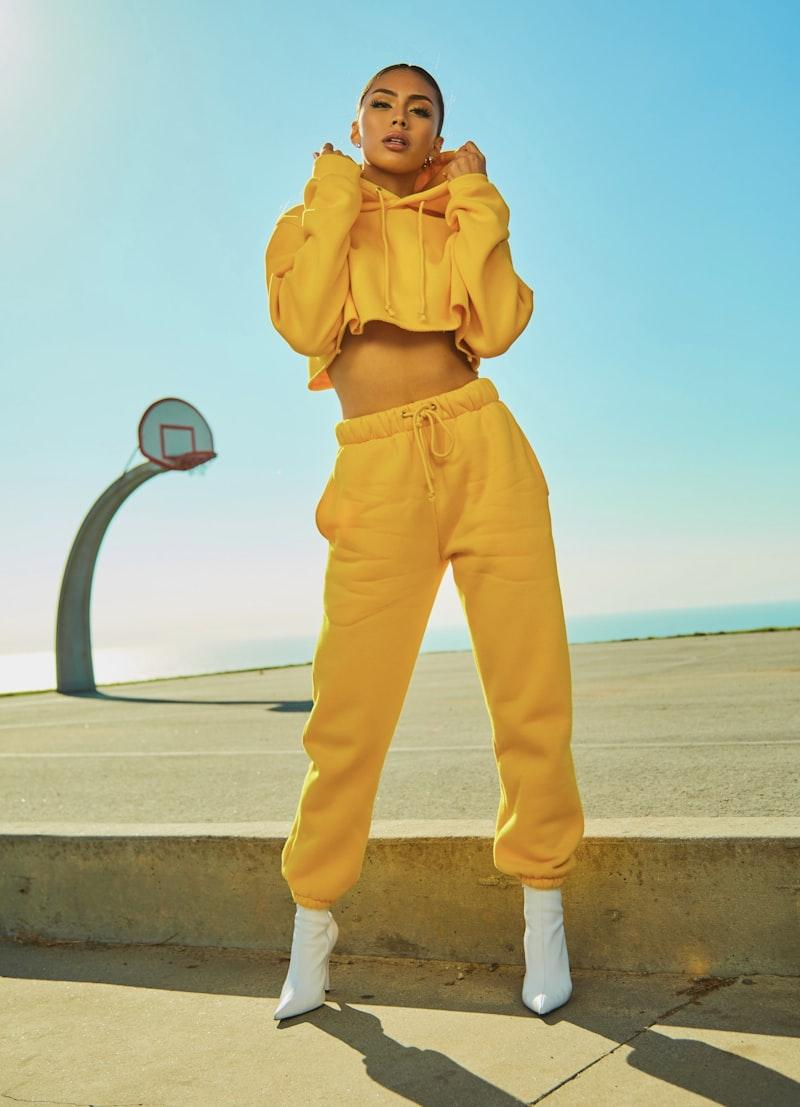

In [18]:
visualize_detections(image, detector._to_dict(detected_products))

In [23]:
import os
import sys
from typing import List, Optional
import numpy as np
import torch
sys.path.append(os.path.abspath("."))

from fashion_detector.config import Config
from fashion_detector.models.florence2 import Florence2Detector
from fashion_detector.models.fashion_clip import FashionClipDetector
from fashion_detector.utils import load_image

def get_present_categories_via_clip(image, classifier, categories_list: List[str], top_k=5, threshold=0.18):
    classifier.load_model()
    
    # 1. Encode text prompts
    text_features = classifier.get_text_features(categories_list) # Shape: (num_cats, D)
    
    # 2. Encode whole image
    inputs = classifier.processor(images=image, return_tensors="pt").to(classifier.device)
    with torch.no_grad():
        image_features = classifier.model.get_image_features(**inputs)
        if hasattr(image_features, "image_embeds"):
            image_features = image_features.image_embeds
        elif hasattr(image_features, "pooler_output"):
            image_features = image_features.pooler_output
        elif not isinstance(image_features, torch.Tensor):
            image_features = image_features[0]
        image_features = image_features / image_features.norm(dim=-1, keepdim=True) # Shape: (1, D)
        
    # 3. Compute cosine similarities
    similarities = (image_features @ text_features.T).cpu().numpy()[0]
    
    # 4. Filter by threshold and take top_k
    valid_indices = np.where(similarities >= threshold)[0]
    
    # Sort indices by similarity descending
    sorted_indices = sorted(valid_indices, key=lambda idx: similarities[idx], reverse=True)
    
    # Limit to top_k
    sorted_indices = sorted_indices[:top_k]
    
    selected_categories = [categories_list[idx] for idx in sorted_indices]
    
    print("\nCLIP Global Similarity scores:")
    for idx in sorted(range(len(categories_list)), key=lambda i: similarities[i], reverse=True)[:10]:
        print(f"  - {categories_list[idx]}: {similarities[idx]:.3f}")
        
    return selected_categories

def run_automatic_narrowing_pipeline(
    image_path: str,
    categories: Optional[List[str]] = None,
    config_path: str = "config/config.yaml"
):
    config = Config(config_path)
    
    # If custom categories are not given, use default list from config
    if not categories:
        categories = config.get_all_categories()
        print("Using default category list from configuration.")
    else:
        print(f"Using custom category list ({len(categories)} classes).")
    
    image = load_image(image_path)
    
    # -------------------------------------------------------------
    # PASS 1: Global Tagging via FashionCLIP (Local, zero API key)
    # -------------------------------------------------------------
    print("Pass 1: Identifying present categories globally via FashionCLIP...")
    classifier = FashionClipDetector(config)
    
    # Find present categories from the supplied categories list
    narrowed_categories = get_present_categories_via_clip(
        image=image,
        classifier=classifier,
        categories_list=categories,
        top_k=5,
        threshold=0.18
    )
    
    print(f"\n-> Narrowed class list down to: {narrowed_categories}\n")
    
    if not narrowed_categories:
        print("No fashion categories identified.")
        return []
        
    # -------------------------------------------------------------
    # PASS 2: Localized Grounding via Florence-2
    # -------------------------------------------------------------
    print("Pass 2: Performing localized grounding using narrowed classes...")
    detector = Florence2Detector(config)
    
    # Run Florence-2 grounding using ONLY the narrowed list of categories
    detections = detector.detect(
        image=image, 
        task="<CAPTION_TO_PHRASE_GROUNDING>", 
        queries=narrowed_categories
    )
    
    print("\n--- Final Florence-2 Detections with Narrowed Vocabulary ---")
    for d in detections:
        print(f"- {d.label.capitalize()} found at {list(map(int, d.box))} (Score: {d.score})")
        
    return detections

if __name__ == "__main__":
    test_image = "data/fashion_model_street.jpg"
    if os.path.exists(test_image):
        print("--- Running test with custom subset ---")
        custom_list = cats[:]
        detections = run_automatic_narrowing_pipeline(test_image, categories=custom_list)
        
        print("\n--- Running test with default config categories ---")
        run_automatic_narrowing_pipeline(test_image)
    else:
        print(f"Image not found at {test_image}")

--- Running test with custom subset ---
[2026-07-21 12:39:11] [INFO] [fashion_detector:config.py:159] - Configuration loaded from config/config.yaml. Device set to: mps
Using custom category list (64 classes).
[2026-07-21 12:39:11] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: data/fashion_model_street.jpg
Pass 1: Identifying present categories globally via FashionCLIP...
[2026-07-21 12:39:11] [INFO] [fashion_detector:fashion_clip.py:32] - Loading FashionCLIP model: patrickjohncyh/fashion-clip on device: mps
[2026-07-21 12:39:15] [INFO] [fashion_detector:fashion_clip.py:45] - FashionCLIP model loaded successfully.
[2026-07-21 12:39:15] [INFO] [fashion_detector:logging.py:98] - Starting: FashionCLIP Text Embeddings
[2026-07-21 12:39:15] [INFO] [fashion_detector:logging.py:103] - Completed: FashionCLIP Text Embeddings in 0.0717 seconds

CLIP Global Similarity scores:
  - jumpsuits: 0.265
  - pants: 0.249
  - pants: 0.249
  - tops: 0.208
  - suits sets: 0.202
  - 


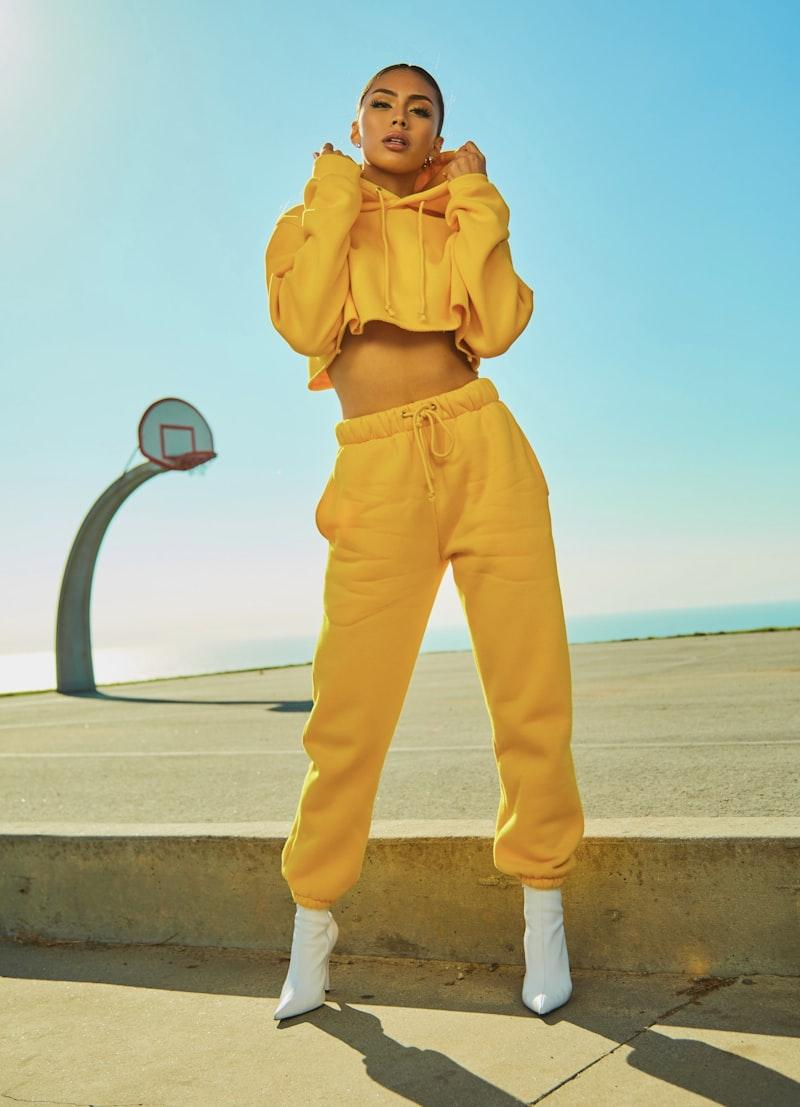

In [24]:
visualize_detections(image, detector._to_dict(detections))

In [26]:
import os
import sys
from typing import List, Dict
import numpy as np
import torch
sys.path.append(os.path.abspath("."))

from fashion_detector.config import Config
from fashion_detector.models.florence2 import Florence2Detector
from fashion_detector.models.fashion_clip import FashionClipDetector
from fashion_detector.utils import load_image
from fashion_detector.models.base import Detection

# Define the category hierarchy to map fine-grained classes to parent detection classes
CATEGORY_GROUPS = {
    "footwear": ["sneakers", "flats", "loafers", "mules slides", "heels", "sandals", "boots", "dress shoes"],
    "bag": ["tote bags", "shoulder bags", "crossbody bags", "handle bags", "backpacks", "belt bags", "clutches", "briefcases", "duffel bags", "messenger bags"],
    "upper body": ["tops", "sweaters", "shirts", "t shirts", "jackets blazers", "coats", "jackets", "blazers"],
    "lower body": ["pants", "jeans", "skirts", "shorts"],
    "one-piece": ["dresses", "suits sets", "jumpsuits", "suits"],
    "jewelry": ["jewelry", "earrings", "necklaces", "bracelets", "rings", "brooches"],
    "headwear": ["hats"],
    "eyewear": ["sunglasses"],
    "belt": ["belts"],
    "scarf": ["scarves shawls", "scarves"],
    "wallet": ["wallets"],
    "watch": ["watches"]
}

# Reverse mapping to look up parent category for a given input class
def build_reverse_mapping() -> Dict[str, str]:
    mapping = {}
    for parent, children in CATEGORY_GROUPS.items():
        for child in children:
            mapping[child.lower().strip()] = parent
    return mapping

def perform_coarse_to_fine_detection(image_path: str, user_cats: List[str], config_path: str = "config/config.yaml"):
    config = Config(config_path)
    image = load_image(image_path)
    
    # 1. Map user classes to their parent categories to run detection
    reverse_map = build_reverse_mapping()
    parent_queries = set()
    
    for cat in user_cats:
        cat_clean = cat.lower().strip()
        parent = reverse_map.get(cat_clean)
        if parent:
            parent_queries.add(parent)
        else:
            # If not in our predefined grouping, use the category name itself as a parent
            parent_queries.add(cat_clean)
            
    parent_queries = list(parent_queries)
    print(f"User requested {len(user_cats)} fine-grained categories.")
    print(f"Mapped to {len(parent_queries)} coarse parent categories for Stage 1 localization:")
    print(f"  {parent_queries}\n")
    
    # 2. Stage 1: Localized Grounding via Florence-2 (Coarse Detections)
    print("Stage 1: Running Florence-2 for coarse localization...")
    detector = Florence2Detector(config)
    coarse_detections = detector.detect(
        image=image,
        task="<CAPTION_TO_PHRASE_GROUNDING>",
        queries=parent_queries
    )
    
    print(f"Florence-2 returned {len(coarse_detections)} region proposals.\n")
    
    # Apply standard NMS on overlapping coarse detections
    # Group boxes by IoU > 0.5 to keep only the best one per region
    filtered_coarse = []
    for det in coarse_detections:
        overlap = False
        for kept in filtered_coarse:
            iou = Florence2Detector.compute_iou(det.box, kept.box)
            if iou > 0.5:
                overlap = True
                break
        if not overlap:
            filtered_coarse.append(det)
            
    print(f"Filtered down to {len(filtered_coarse)} unique regions after NMS.\n")
    
    # 3. Stage 2: Fine-grained classification via FashionCLIP on Crops
    print("Stage 2: Refining region classes using FashionCLIP crop classification...")
    classifier = FashionClipDetector(config)
    classifier.load_model()
    
    final_detections = []
    w, h = image.size
    
    for det in filtered_coarse:
        # Determine the candidate subcategories for this region's parent category
        parent = det.label.lower().strip()
        
        # Get subset of user requested categories belonging to this parent group
        candidate_children = CATEGORY_GROUPS.get(parent, [])
        valid_candidates = [c for c in user_cats if c.lower().strip() in candidate_children]
        
        # Fallback if no subcategories match (e.g. if the parent itself was a custom user cat)
        if not valid_candidates:
            valid_candidates = [det.label]
            
        print(f"Crop '{parent}' will be classified against: {valid_candidates}")
        
        # Crop the region of interest
        xmin, ymin, xmax, ymax = det.box
        crop = image.crop((
            max(0, int(xmin)),
            max(0, int(ymin)),
            min(w, int(xmax)),
            min(h, int(ymax))
        ))
        
        # Perform FashionCLIP classification on the crop against candidates
        text_features = classifier.get_text_features(valid_candidates)
        inputs = classifier.processor(images=crop, return_tensors="pt").to(classifier.device)
        
        with torch.no_grad():
            image_features = classifier.model.get_image_features(**inputs)
            if hasattr(image_features, "image_embeds"):
                image_features = image_features.image_embeds
            elif hasattr(image_features, "pooler_output"):
                image_features = image_features.pooler_output
            elif not isinstance(image_features, torch.Tensor):
                image_features = image_features[0]
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            
            similarity = (image_features @ text_features.T) * classifier.model.logit_scale.exp()
            probs = similarity.softmax(dim=-1).cpu().numpy()[0]
            
        best_idx = np.argmax(probs)
        best_score = float(probs[best_idx])
        best_label = valid_candidates[best_idx]
        
        final_detections.append(
            Detection(
                box=det.box,
                label=best_label,
                score=best_score,
                metadata={"coarse_label": parent, "probabilities": probs.tolist()}
            )
        )
        
    print("\n--- Final Hierarchical Detections ---")
    for d in final_detections:
        print(f"- {d.label} ({d.metadata['coarse_label']}) -> Score: {d.score:.2f} at box {list(map(int, d.box))}")
        
    return final_detections

if __name__ == "__main__":
    test_image = "data/fashion_model_street.jpg"
    
    # User's large/confusing categories list
    user_categories = [
        'dresses', 'tops', 'sweaters', 'shirts', 'jackets blazers', 'coats', 'pants', 'jeans', 'skirts', 
        'suits sets', 'jumpsuits', 'sneakers', 'flats', 'loafers', 'mules slides', 'heels', 'sandals', 
        'boots', 'tote bags', 'shoulder bags', 'crossbody bags', 'handle bags', 'backpacks', 'belt bags', 
        'clutches', 'sunglasses', 'scarves shawls', 'belts', 'wallets', 'hats', 'watches', 'jewelry', 
        'earrings', 'necklaces', 'bracelets', 'rings', 'brooches', 't shirts', 'shirts', 'sweaters', 
        'jackets', 'blazers', 'coats', 'pants', 'jeans', 'suits', 'shorts', 'dress shoes', 'loafers', 
        'sneakers', 'boots', 'sandals', 'briefcases', 'backpacks', 'duffel bags', 'messenger bags', 
        'tote bags', 'sunglasses', 'belts', 'ties', 'scarves', 'wallets', 'hats', 'watches'
    ]
    
    # Remove exact string duplicates to clean up a bit
    user_categories = list(set(user_categories))
    
    if os.path.exists(test_image):
        new_detections = perform_coarse_to_fine_detection(test_image, user_categories)
    else:
        print(f"Image not found at {test_image}")


[2026-07-21 12:43:48] [INFO] [fashion_detector:config.py:159] - Configuration loaded from config/config.yaml. Device set to: mps
[2026-07-21 12:43:48] [INFO] [fashion_detector:utils.py:32] - Loading image from local path: data/fashion_model_street.jpg
User requested 48 fine-grained categories.
Mapped to 13 coarse parent categories for Stage 1 localization:
  ['bag', 'eyewear', 'footwear', 'jewelry', 'one-piece', 'headwear', 'watch', 'ties', 'scarf', 'lower body', 'upper body', 'wallet', 'belt']

Stage 1: Running Florence-2 for coarse localization...
[2026-07-21 12:43:48] [INFO] [fashion_detector:florence2.py:22] - Florence-2 Detector initialized with model: microsoft/Florence-2-base, confidence threshold: 0.3
[2026-07-21 12:43:48] [INFO] [fashion_detector:florence2.py:25] - Florence-2 Detector default lifestyle categories: ['shirt', 't-shirt', 'polo', 'sweater', 'hoodie', 'jacket', 'blazer', 'coat', 'dress', 'top', 'jeans', 'pants', 'shorts', 'skirt', 'suit', 'jumpsuit', 'scarf', 'hand


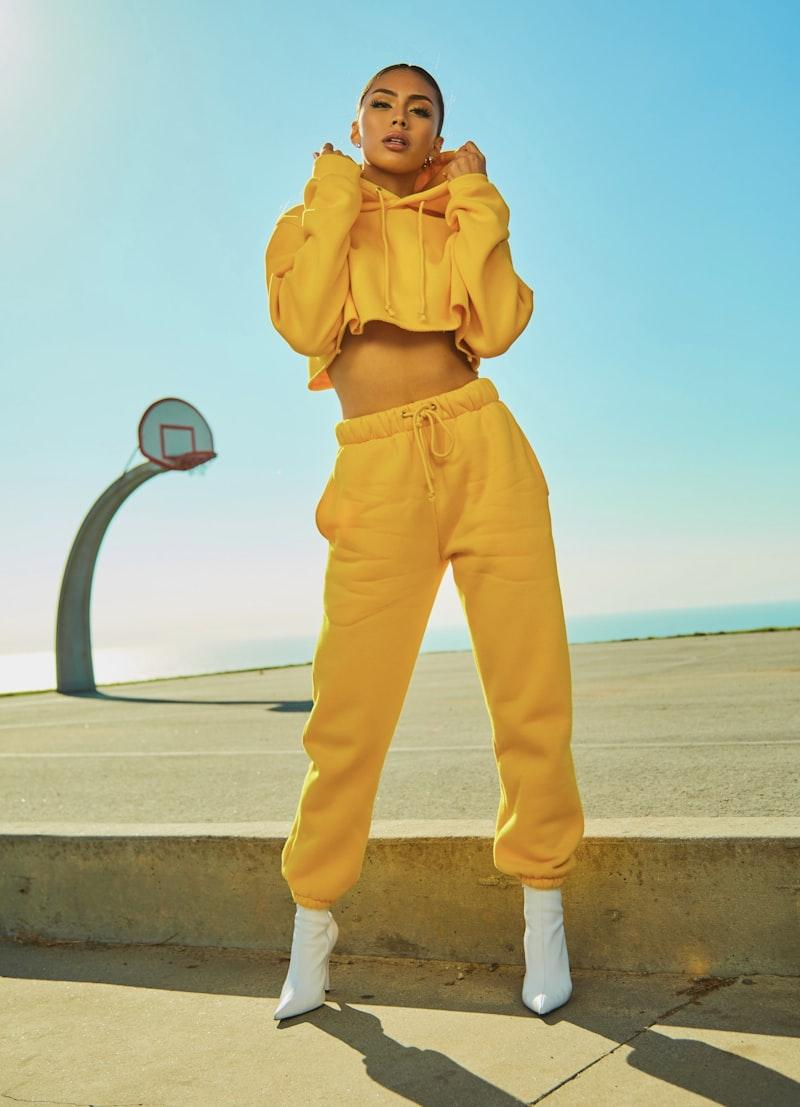

In [27]:
visualize_detections(image, detector._to_dict(new_detections))